In [1]:
import os.path
from secrets import randbelow
from statistics import median

import pandas as pd
import numpy as np
from numpy.ma.core import shape

COMPOSITES_NO_NAN_DIR = "/run/media/martin/KINGSTON/NDVI/test_area_no_nan"
COMPOSITES_NO_NAN_LOG_PATH = os.path.join(COMPOSITES_NO_NAN_DIR, "log.csv")

In [2]:
inventory = pd.read_csv(COMPOSITES_NO_NAN_LOG_PATH, index_col=0, header = 0)

min_year = inventory.year.min()
max_year = inventory.year.max()

min_month = inventory.month.min()
max_month = inventory.month.max() 

inventory = inventory.set_index(["year", "month"])


#### Vizualization

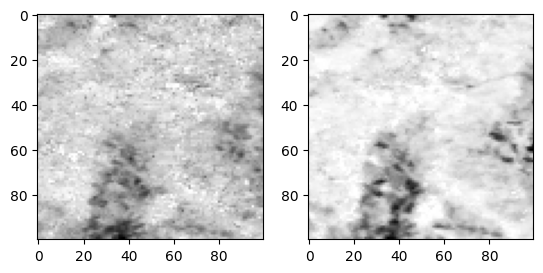

In [13]:
from matplotlib import pyplot as plt

path_start = inventory.loc[(2018, 6)]["path"]
sample_start = np.load(path_start)

path_end = inventory.loc[(2023,6)]["path"]
sample_end = np.load(path_end)

fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.imshow(sample_start, cmap=plt.get_cmap("gray"))
ax2.imshow(sample_end, cmap=plt.get_cmap("gray"))

plt.show()


####  backward differences

In [3]:
composite_matrix = [] # [year, month]

for year in range(min_year,max_year+1):
    composite_matrix.append([])
    for month in range(min_month,max_month+1):
        new_composit = np.load(inventory.loc[(year,month)]["path"])
        composite_matrix[-1].append(new_composit)


doen


In [5]:
composite_matrix = np.array(composite_matrix)
print(composite_matrix.shape)

(6, 5, 100, 100)


In [6]:
X_BD = np.empty(composite_matrix.shape) #Back diference
X_BD[:] = np.nan


for i in range(1, composite_matrix.shape[0]):
    X_BD[i,:] = composite_matrix[i,:] - composite_matrix[i-1,:]
    

done


In [11]:
# check of BD computation
for m in range(0, composite_matrix.shape[1]):
    for yr in  range(1, composite_matrix.shape[0]):
        for x in range(1, composite_matrix.shape[2]):
            for y in range(1, composite_matrix.shape[3]):
                expected = composite_matrix[yr,m,x,y] - composite_matrix[yr-1,m,x,y]
                calculated = X_BD[yr,m,x,y]
                
                if expected != calculated:
                    raise Exception (f"Value {calculated} does not match expected {expected} at {yr},{m},{x},{y}")

#### Visualize

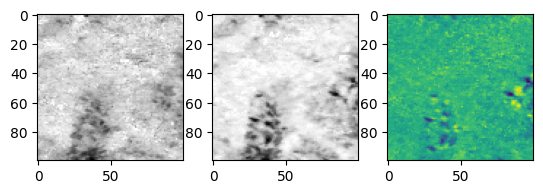

[[ 9. 15. 14. ... 23. 10. 14.]
 [11. 22. 16. ... 16. 23. 30.]
 [15. 17.  9. ...  7.  6. -9.]
 ...
 [15. 22. 18. ... 11. 17. 10.]
 [20. 23. 35. ...  8. 15.  5.]
 [30. 29. 29. ...  3.  9. 12.]]


In [23]:
fig, ax = plt.subplots(1,3)

ax[0].imshow(composite_matrix[0,0], cmap=plt.get_cmap("gray"))
ax[1].imshow(composite_matrix[1,0], cmap=plt.get_cmap("gray"))

ax[2].imshow(X_BD[1,0])


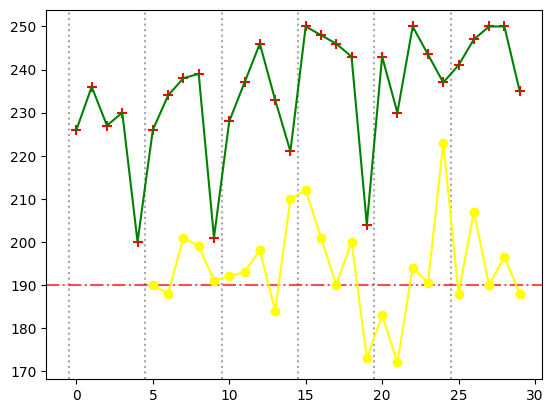

In [77]:
OBSERVED_POINT = [21,40]
#OBSERVED_POINT = [40,80]
#OBSERVED_POINT = [40,99]
FAKE_ZERO_LINE = 190

time_serie_one_point = []
time_serie_bd = []
counter = -0.5
for y in range(composite_matrix.shape[0]):
    plt.axvline(x=counter, color='gray', linestyle=':', alpha=0.7)
    for m in range(composite_matrix.shape[1]):
        time_serie_one_point.append(composite_matrix[y,m,OBSERVED_POINT[0],OBSERVED_POINT[1]])
        time_serie_bd.append(X_BD[y,m,OBSERVED_POINT[0],OBSERVED_POINT[1]]+FAKE_ZERO_LINE)
        counter += 1
        

plt.plot(time_serie_one_point, color='green')
plt.scatter(y=time_serie_one_point, x=range(len(time_serie_one_point)), color='red', marker='+', alpha=1, s=50)

plt.axhline(y = FAKE_ZERO_LINE, color='red', linestyle='-.', alpha=0.7)
plt.plot(time_serie_bd, color='yellow', marker='o')

plt.show()